In [ ]:
  import json
  import numpy as np
  from collections import defaultdict
  from pathlib import Path
  from datetime import timedelta
  import matplotlib.pyplot as plt
  from tqdm import tqdm

  print("\n✅ Libraries imported successfully")


✅ Libraries imported successfully


In [ ]:
  #cell2
  from google.colab import drive
  drive.mount('/content/drive')

  # CONFIGURATION - CORRECTED PATHS
  PHASE1B_DATA_DIR = "/content/drive/MyDrive/ExamLens/phase1b_output/"
  PHASE1A_DATA_DIR = "/content/drive/MyDrive/ExamLens/phase1a_output/"
  PHASE2_OUTPUT_DIR = "/content/drive/MyDrive/ExamLens/examlens_phase2_events_big/"
  Path(PHASE2_OUTPUT_DIR).mkdir(exist_ok=True)

  # Input files from Phase 1B
  TRACKING_DATA_FILE = f"{PHASE1B_DATA_DIR}tracking_data.json"
  MOTION_TIMELINE_FILE = f"{PHASE1B_DATA_DIR}motion_timeline.json"
  SUMMARY_FILE = f"{PHASE1B_DATA_DIR}summary.json"

  print("\n📁 Configuration:")
  print(f"   Phase 1A data: {PHASE1A_DATA_DIR}")
  print(f"   Phase 1B data: {PHASE1B_DATA_DIR}")
  print(f"   Phase 2 output: {PHASE2_OUTPUT_DIR}")

  # Verify input files exist
  print("\n🔍 Checking Phase 1B output files:")
  all_exist = True
  for filepath in [TRACKING_DATA_FILE, MOTION_TIMELINE_FILE, SUMMARY_FILE]:
      exists = Path(filepath).exists()
      status = "✅" if exists else "❌"
      print(f"   {status} {Path(filepath).name}")
      if not exists:
          all_exist = Falseprint(f"      Expected at: {filepath}")

  if not all_exist:
      print("\n⚠️  WARNING: Some files missing!")
      print("   Options:")
      print("   1. Check if Phase 1B saved files to different location")
      print("   2. Re-run Phase 1B backup cell to save files")
      print("   3. Update paths above to match your actual location")
  else:
      print("\n✅ All input files found! Ready to proceed.")

Mounted at /content/drive

📁 Configuration:
   Phase 1A data: /content/drive/MyDrive/ExamLens/phase1a_output/
   Phase 1B data: /content/drive/MyDrive/ExamLens/phase1b_output/
   Phase 2 output: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big/

🔍 Checking Phase 1B output files:
   ✅ tracking_data.json
   ✅ motion_timeline.json
   ✅ summary.json

✅ All input files found! Ready to proceed.


In [ ]:
  # CELL 2.5: Exam Type Configuration (NEW)
  #----------------------------------------------------------------------------
  print("\n📋 EXAM TYPE CONFIGURATION")
  print("="*60)

  # USER INPUT: Set exam type for this video
  EXAM_TYPE = "PAPER_PEN"  # Options: "CBT", "PAPER_PEN", "PHYSICAL", "HYBRID"

  # Exam profiles with detection settings
  EXAM_PROFILES = {
      "CBT": {
          "description": "Computer-Based Test - Students use laptops throughout exam",
          "laptop_detection": False,
          "laptop_severity": "LOW",
          "movement_threshold": 0.85,
          "stillness_threshold": 0.10,
      },
      "PAPER_PEN": {
          "description": "Paper-Based Exam - No electronic devices allowed",
          "laptop_detection": True,
          "laptop_severity": "HIGH",
          "movement_threshold": 0.7,
          "stillness_threshold": 0.15,
      },
      "PHYSICAL": {
          "description": "Physical Fitness Test - High movement expected",
          "laptop_detection": True,
          "laptop_severity": "HIGH",
          "movement_threshold": 999,  # Disabled
          "stillness_threshold": 0.20,
      },
      "HYBRID": {
          "description": "Mixed Format Exam",
          "laptop_detection": True,
          "laptop_severity": "MEDIUM",
          "movement_threshold": 0.7,
          "stillness_threshold": 0.15,
      }
  }

  EXAM_PROFILE = EXAM_PROFILES.get(EXAM_TYPE, EXAM_PROFILES["HYBRID"])

  print(f"✅ Exam Type: {EXAM_TYPE}")
  print(f"   📝 {EXAM_PROFILE['description']}")
  print(f"\n⚙️  Detection Settings:")
  print(f"   Laptop Detection: {'ENABLED' if EXAM_PROFILE['laptop_detection'] else 'DISABLED'}")
  print(f"   Laptop Severity: {EXAM_PROFILE.get('laptop_severity', 'N/A')}")
  print(f"   Movement Threshold: {EXAM_PROFILE['movement_threshold']}")
  print(f"   Stillness Threshold: {EXAM_PROFILE['stillness_threshold']}")
  print("="*60)


📋 EXAM TYPE CONFIGURATION
✅ Exam Type: PAPER_PEN
   📝 Paper-Based Exam - No electronic devices allowed

⚙️  Detection Settings:
   Laptop Detection: ENABLED
   Laptop Severity: HIGH
   Movement Threshold: 0.7
   Stillness Threshold: 0.15


In [ ]:
  # CELL 3: Event Detection Configuration (UPDATED - EXAM-AWARE)
  #----------------------------------------------------------------------------


  # EVENT DETECTION CONFIGURATION
  EVENT_CONFIG = {
      # Event1: Laptop Interaction (exam-type aware)
      "LAPTOP_INTERACTION": {
          "enabled": EXAM_PROFILE['laptop_detection'],
          "proximity_threshold": 150,  # pixels - max person-laptop distance
          "min_duration": 5.0,  # seconds - minimum to flag
          "max_duration": 120.0,  # seconds - maximum to flag (filters continuous exam use)
          "merge_gap": 5.0,  # seconds - larger gap to separate checking from continuous use
          "severity": EXAM_PROFILE.get('laptop_severity', 'MEDIUM'),
          "color": "red" if EXAM_PROFILE.get('laptop_severity') == 'HIGH' else "orange",
          "description": f"Laptop interaction detected during {EXAM_TYPE} exam"
      },

      # Event 2: Suspicious Stillness (exam-type aware)
      "SUSPICIOUS_STILLNESS": {
          "enabled": True,
          "motion_threshold": EXAM_PROFILE['stillness_threshold'],  # From exam profile
          "min_duration": 5.0,  # seconds
          "merge_gap": 3.0,  # seconds
          "severity": "HIGH",
          "color": "red",
          "description": "Prolonged stillness detected - potential hidden device usage"
      },

      # Event 3: Excessive Movement (exam-type aware)
      "EXCESSIVE_MOVEMENT": {
          "enabled": EXAM_PROFILE['movement_threshold'] < 999,  # Disabled if threshold is 999
          "motion_threshold": EXAM_PROFILE['movement_threshold'],  # From exam profile
          "min_duration": 10.0,  # seconds
          "merge_gap": 3.0,  # seconds
          "severity": "MEDIUM",
          "color": "yellow",
          "description": "Sustained excessive movement detected"
      }
  }

  # GENERAL SETTINGS
  MIN_EVENT_CONFIDENCE = 0.5  # Filter out low-confidence events
  EVENT_MERGE_GAP_GLOBAL = 2.0  # Default merge gap

  print("⚙️  Event Detection Configuration:")
  print("="*60)
  print(f"\n🎯 Exam Type: {EXAM_TYPE}")
  print(f"   {EXAM_PROFILE['description']}")

  print(f"\n📋 Active Events:")
  for event_type, config in EVENT_CONFIG.items():
      if config['enabled']:
          print(f"\n✅ {event_type}:")
          print(f"      Duration: {config['min_duration']}s", end="")
          if'max_duration' in config:
              print(f" - {config['max_duration']}s (filters continuous use)")
          else:
              print()
          print(f"      Severity: {config['severity']}")
          print(f"      Merge gap: {config['merge_gap']}s")
          if 'proximity_threshold' in config:
              print(f"      Proximity: {config['proximity_threshold']}px")
          if 'motion_threshold' in config:
              thresh = config['motion_threshold']
              if thresh < 999:
                  operator = '<' if 'STILLNESS' in event_type else '>'
                  print(f"      Motion: {operator} {thresh}")
              else:
                 print(f"\n❌ {event_type}: DISABLED for {EXAM_TYPE} exam")

  print("\n" + "="*60)
  if EXAM_TYPE == "CBT":
      print("💡 Note: Laptop detection disabled (continuous use expected in CBT)")
  elif EXAM_TYPE == "PHYSICAL":
      print("💡 Note: Movement detection disabled (high activity expected)")
  elif EXAM_TYPE == "PAPER_PEN":
      print("💡 Note: Laptop interactions flagged as HIGH severity (no devices allowed)")
  print("="*60)


⚙️  Event Detection Configuration:

🎯 Exam Type: PAPER_PEN
   Paper-Based Exam - No electronic devices allowed

📋 Active Events:

✅ LAPTOP_INTERACTION:
      Duration: 5.0s - 120.0s (filters continuous use)
      Severity: HIGH
      Merge gap: 5.0s
      Proximity: 150px

✅ SUSPICIOUS_STILLNESS:
      Duration: 5.0s
      Severity: HIGH
      Merge gap: 3.0s
      Motion: < 0.15

✅ EXCESSIVE_MOVEMENT:
      Duration: 10.0s
      Severity: MEDIUM
      Merge gap: 3.0s
      Motion: > 0.7

💡 Note: Laptop interactions flagged as HIGH severity (no devices allowed)


In [ ]:
  # CELL 4: Load Phase 1B Data
  #----------------------------------------------------------------------------
  print("\n📂 Loading Phase 1B tracking data...")
  print("="*60)

  # Load tracking data (frame-by-frame detections)
  with open(TRACKING_DATA_FILE, 'r') as f:
      tracking_data = json.load(f)
  print(f"✅ Tracking data: {len(tracking_data)} frames")

  # Load motion timeline (per-person motion scores)
  with open(MOTION_TIMELINE_FILE, 'r') as f:
      motion_timeline = json.load(f)
  print(f"✅ Motion timeline: {len(motion_timeline)} persons")

  # Load summary statistics
  with open(SUMMARY_FILE, 'r') as f:
      summary = json.load(f)
  print(f"✅ Summary: {summary['total_detections']} detections")

  # Build indices for fast lookup
  print("\n🔨 Building lookup indices...")

  # Person track index: {person_id: [list of detections]}
  person_tracks = defaultdict(list)
  for frame_data in tracking_data:
      for det in frame_data['detections']:
          if det['class'] == 'person':
              person_tracks[det['track_id']].append({
                  'frame': frame_data['frame'],
                  'timestamp': frame_data['timestamp'],
                  'bbox': det['bbox'],
                  'motion_score': det.get('motion_score', 0.0),
                  'confidence': det['confidence']
              })

  print(f"✅ Indexed {len(person_tracks)} unique persons")

  # Show sample
  print(f"\n📊 Sample person tracks:")
  for person_id in list(person_tracks.keys())[:5]:
      track_length = len(person_tracks[person_id])
      if track_length > 0:
          duration = (person_tracks[person_id][-1]['timestamp'] -
                     person_tracks[person_id][0]['timestamp'])
          print(f"   Person {person_id}: {track_length} detections, {duration:.1f}s duration")

  print("\n" + "="*60)
  print("✅ Data loaded and indexed successfully!")


📂 Loading Phase 1B tracking data...
✅ Tracking data: 177363 frames
✅ Motion timeline: 2603 persons
✅ Summary: 519102 detections

🔨 Building lookup indices...
✅ Indexed 2283 unique persons

📊 Sample person tracks:
   Person 1: 98 detections, 4.4s duration
   Person 2: 4117 detections, 193.1s duration
   Person 3: 243 detections, 13.0s duration
   Person 4: 50 detections, 3.9s duration
   Person 5: 94 detections, 4.6s duration

✅ Data loaded and indexed successfully!


In [ ]:
  # CELL 5: Helper Functions
  #----------------------------------------------------------------------------

  def calculate_distance(bbox1, bbox2):
      """Calculate Euclidean distance between bbox centers."""
      cx1 = (bbox1[0] + bbox1[2]) / 2
      cy1 = (bbox1[1] + bbox1[3]) / 2
      cx2 = (bbox2[0] + bbox2[2]) / 2
      cy2 = (bbox2[1] + bbox2[3]) / 2
      return np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)


  def calculate_bbox_aspect_ratio(bbox):
      """Calculate bbox aspect ratio (height/width)."""
      width = bbox[2] - bbox[0]
      height = bbox[3] - bbox[1]
      return height / width if width > 0 else 1.0


  def calculate_event_confidence(event_type, duration, signal_strength):
      """Calculate confidence score for an event."""
      base_confidence = signal_strength
      duration_bonus = min(0.2, duration / 50.0)

      type_multipliers = {
          'LAPTOP_INTERACTION': 0.85,
          'SUSPICIOUS_STILLNESS': 0.9,
          'EXCESSIVE_MOVEMENT': 0.75
      }

      multiplier = type_multipliers.get(event_type, 0.8)
      confidence = (base_confidence + duration_bonus) * multiplier
      return min(1.0, max(0.0, confidence))


  def merge_consecutive_events(events, max_gap=2.0):
      """Merge events of same type that are close in time."""
      if len(events) == 0:
          return []

      events = sorted(events, key=lambda x: x['start_time'])
      merged = []
      current = events[0].copy()

      for event in events[1:]:
          if (event['event_type'] == current['event_type'] and
              event['person_id'] == current['person_id'] and
              event['start_time'] - current['end_time'] <= max_gap):
              current['end_time'] = event['end_time']
              current['duration'] = current['end_time'] - current['start_time']
              current['confidence'] = max(current['confidence'], event['confidence'])
          else:
              merged.append(current)
              current = event.copy()

      merged.append(current)
      return merged


  def format_timestamp(seconds):
      """Convert seconds to MM:SS format."""
      mins = int(seconds // 60)
      secs = int(seconds % 60)
      return f"{mins:02d}:{secs:02d}"


  print("✅ Helper functions defined")

✅ Helper functions defined


In [ ]:
  # CELL 6: Detect Laptop Interaction Events
  #----------------------------------------------------------------------------
  print("\n" + "="*60)
  print("🔍 DETECTING LAPTOP INTERACTION EVENTS")
  print("="*60)

  all_events = []
  config = EVENT_CONFIG['LAPTOP_INTERACTION']

  if config['enabled']:
      laptop_interactions = []

      for frame_data in tqdm(tracking_data, desc="Scanning laptop interactions"):
          persons = [d for d in frame_data['detections'] if d['class'] == 'person']
          laptops = [d for d in frame_data['detections'] if d['class'] == 'laptop']

          for person in persons:
              for laptop in laptops:
                  distance = calculate_distance(person['bbox'], laptop['bbox'])

                  if distance < config['proximity_threshold']:
                      laptop_interactions.append({
                          'frame': frame_data['frame'],
                          'timestamp': frame_data['timestamp'],
                          'person_id': person['track_id'],
                          'distance': distance
                      })

      print(f"\n📊 Found {len(laptop_interactions)} frame-level interactions")

      # Convert to events
      if len(laptop_interactions) > 0:
          person_interactions = defaultdict(list)
          for interaction in laptop_interactions:
              person_interactions[interaction['person_id']].append(interaction)

          for person_id, interactions in person_interactions.items():
              interactions = sorted(interactions, key=lambda x: x['timestamp'])

              start_time = interactions[0]['timestamp']
              end_time = interactions[0]['timestamp']

              for i in range(1, len(interactions)):
                  gap = interactions[i]['timestamp'] - end_time

                  if gap <= config['merge_gap']:
                      end_time = interactions[i]['timestamp']
                  else:
                      duration = end_time - start_time

                      # Apply duration filter (5s - 120s)
                      if config['min_duration'] <= duration <= config['max_duration']:
                          all_events.append({
                              'event_type': 'LAPTOP_INTERACTION',
                              'person_id': person_id,
                              'start_time': start_time,
                              'end_time': end_time,
                              'duration': duration,
                              'severity': config['severity'],
                              'confidence': calculate_event_confidence('LAPTOP_INTERACTION', duration, 0.85),
                              'description': 'Brief laptop interaction detected'
                          })

                      start_time = interactions[i]['timestamp']
                      end_time = interactions[i]['timestamp']

              # Check last event
              duration = end_time - start_time
              if config['min_duration'] <= duration <= config['max_duration']:
                  all_events.append({
                      'event_type': 'LAPTOP_INTERACTION',
                      'person_id': person_id,
                      'start_time': start_time,
                      'end_time': end_time,
                      'duration': duration,
                      'severity': config['severity'],
                      'confidence': calculate_event_confidence('LAPTOP_INTERACTION', duration, 0.85),
                      'description': 'Brief laptop interaction detected'
                  })

      laptop_events_count = len([e for e in all_events if e['event_type'] == 'LAPTOP_INTERACTION'])
      print(f"✅ Detected {laptop_events_count} LAPTOP_INTERACTION events (filtered5-120s)")
  else:
      print("⏭️  LAPTOP_INTERACTION detection disabled")


🔍 DETECTING LAPTOP INTERACTION EVENTS


Scanning laptop interactions: 100%|██████████| 177363/177363 [00:00<00:00, 539887.19it/s]


📊 Found 4482 frame-level interactions
✅ Detected 27 LAPTOP_INTERACTION events (filtered5-120s)


In [ ]:
  # CELL 7: Detect Suspicious Stillness Events
  #----------------------------------------------------------------------------
  print("\n" + "="*60)
  print("🔍 DETECTING SUSPICIOUS STILLNESS EVENTS")
  print("="*60)

  config = EVENT_CONFIG['SUSPICIOUS_STILLNESS']

  if config['enabled']:
      for person_id, track in person_tracks.items():
          if len(track) < 2:
              continue

          still_start = None
          still_duration = 0

          for detection in track:
              motion = detection['motion_score']

              if motion < config['motion_threshold']:
                  if still_start is None:
                      still_start = detection['timestamp']
                  still_duration = detection['timestamp'] - still_start
              else:
                  if still_start is not None and still_duration >= config['min_duration']:
                      all_events.append({
                          'event_type': 'SUSPICIOUS_STILLNESS',
                          'person_id': person_id,
                          'start_time': still_start,
                          'end_time': still_start + still_duration,
                          'duration': still_duration,
                          'severity': config['severity'],
                          'confidence': calculate_event_confidence('SUSPICIOUS_STILLNESS', still_duration, 0.8),
                          'description': 'Prolonged stillness - potential hidden device usage'
                      })

                  still_start = None
                  still_duration = 0

          # Check final period
          if still_start is not None and still_duration >= config['min_duration']:
              all_events.append({
                  'event_type': 'SUSPICIOUS_STILLNESS',
                  'person_id': person_id,
                  'start_time': still_start,
                  'end_time': still_start + still_duration,
                  'duration': still_duration,
                  'severity': config['severity'],
                  'confidence': calculate_event_confidence('SUSPICIOUS_STILLNESS', still_duration, 0.8),
                  'description': 'Prolonged stillness - potential hidden device usage'
              })

      stillness_count = len([e for e in all_events if e['event_type'] == 'SUSPICIOUS_STILLNESS'])
      print(f"✅ Detected {stillness_count} SUSPICIOUS_STILLNESS events")
  else:
      print("⏭️  SUSPICIOUS_STILLNESS detection disabled")


🔍 DETECTING SUSPICIOUS STILLNESS EVENTS
✅ Detected 740 SUSPICIOUS_STILLNESS events


In [ ]:

  # CELL 8: Detect Excessive Movement Events
  #----------------------------------------------------------------------------
  print("\n" + "="*60)
  print("🔍 DETECTING EXCESSIVE MOVEMENT EVENTS")
  print("="*60)

  config = EVENT_CONFIG['EXCESSIVE_MOVEMENT']

  if config['enabled']:
      for person_id, track in person_tracks.items():
          if len(track) < 2:
              continue

          movement_start = None
          movement_duration = 0

          for detection in track:
              motion = detection['motion_score']

              if motion > config['motion_threshold']:
                  if movement_start is None:
                      movement_start = detection['timestamp']
                  movement_duration = detection['timestamp'] - movement_start
              else:
                  if movement_start is not None and movement_duration >= config['min_duration']:
                      all_events.append({
                          'event_type': 'EXCESSIVE_MOVEMENT',
                          'person_id': person_id,
                          'start_time': movement_start,
                          'end_time': movement_start + movement_duration,
                          'duration': movement_duration,
                          'severity': config['severity'],
                          'confidence': calculate_event_confidence('EXCESSIVE_MOVEMENT', movement_duration, 0.7),
                          'description': 'Sustained excessive movement detected'
                      })

                  movement_start = None
                  movement_duration = 0

          # Check final period
          if movement_start is not None and movement_duration >= config['min_duration']:
              all_events.append({
                  'event_type': 'EXCESSIVE_MOVEMENT',
                  'person_id': person_id,
                  'start_time': movement_start,
                  'end_time': movement_start + movement_duration,
                  'duration': movement_duration,
                  'severity': config['severity'],
                  'confidence': calculate_event_confidence('EXCESSIVE_MOVEMENT', movement_duration, 0.7),
                  'description': 'Sustained excessive movement detected'
              })

      movement_count = len([e for e in all_events if e['event_type'] == 'EXCESSIVE_MOVEMENT'])
      print(f"✅ Detected {movement_count} EXCESSIVE_MOVEMENT events")
  else:
      print("⏭️  EXCESSIVE_MOVEMENT detection disabled")


🔍 DETECTING EXCESSIVE MOVEMENT EVENTS
✅ Detected 25 EXCESSIVE_MOVEMENT events


In [ ]:
  # CELL 9: Merge & Filter Events
  #----------------------------------------------------------------------------
  print("\n" + "="*60)
  print("🔧 MERGING & FILTERING EVENTS")
  print("="*60)

  print(f"\n📊 Before merging: {len(all_events)} events")

  # Merge consecutive events of same type
  all_events = merge_consecutive_events(all_events, max_gap=EVENT_MERGE_GAP_GLOBAL)

  print(f"📊 After merging: {len(all_events)} events")

  # Filter by confidence
  filtered_events = [e for e in all_events if e['confidence'] >= MIN_EVENT_CONFIDENCE]

  print(f"📊 After confidence filter (>={MIN_EVENT_CONFIDENCE}): {len(filtered_events)} events")

  # Sort by severity then time
  severity_order = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
  filtered_events = sorted(filtered_events, key=lambda x: (severity_order.get(x['severity'], 3), x['start_time']))

  # Assign event IDs
  for i, event in enumerate(filtered_events, 1):
      event['event_id'] = i
      event['start_time_formatted'] = format_timestamp(event['start_time'])
      event['end_time_formatted'] = format_timestamp(event['end_time'])

  print(f"\n✅ Final event count: {len(filtered_events)}")

  # Summary by type
  event_summary = defaultdict(int)
  for event in filtered_events:
      event_summary[event['event_type']] += 1

  print(f"\n📊 Events by type:")
  for event_type, count in sorted(event_summary.items(), key=lambda x: x[1], reverse=True):
      print(f"   {event_type}: {count}")

  # Summary by severity
  severity_summary = defaultdict(int)
  for event in filtered_events:
      severity_summary[event['severity']] += 1

  print(f"\n📊 Events by severity:")
  for severity in ['HIGH', 'MEDIUM', 'LOW']:
      count = severity_summary.get(severity, 0)
      print(f"   {severity}: {count}")




🔧 MERGING & FILTERING EVENTS

📊 Before merging: 792 events
📊 After merging: 754 events
📊 After confidence filter (>=0.5): 754 events

✅ Final event count: 754

📊 Events by type:
   SUSPICIOUS_STILLNESS: 702
   LAPTOP_INTERACTION: 27
   EXCESSIVE_MOVEMENT: 25

📊 Events by severity:
   HIGH: 729
   MEDIUM: 25
   LOW: 0


In [ ]:

  # cell 10 Save to JSON
  events_output = {
      'metadata': {
          'total_events': len(filtered_events),
          'video_frames': len(tracking_data),
          'persons_tracked': len(person_tracks),
          'detection_config': EVENT_CONFIG,
          'events_by_type': dict(event_summary),
          'events_by_severity': dict(severity_summary)
      },
      'events': filtered_events
  }

  events_json_path = f"{PHASE2_OUTPUT_DIR}/events.json"
  with open(events_json_path, 'w') as f:
      json.dump(events_output, f, indent=2)

  print(f"✅ Events saved: {events_json_path}")

  # Save to Drive for persistence
  drive_output = "/content/drive/MyDrive/ExamLens/phase2_output_big/"
  Path(drive_output).mkdir(parents=True, exist_ok=True)

  import shutil
  shutil.copy(events_json_path, f"{drive_output}/events.json")

  print(f"✅ Backup saved: {drive_output}/events.json")

  # Display top10 events
  print(f"\n🔝 TOP 10 EVENTS (by severity & time):")
  print("-" * 80)
  for event in filtered_events[:10]:
      print(f"{event['event_id']:3d}. [{event['severity']:6s}] {event['event_type']:25s} | "
            f"Person {event['person_id']:3d} | {event['start_time_formatted']} - {event['end_time_formatted']} | "
            f"{event['duration']:.1f}s | Conf: {event['confidence']:.2f}")


✅ Events saved: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big//events.json
✅ Backup saved: /content/drive/MyDrive/ExamLens/phase2_output_big//events.json

🔝 TOP 10 EVENTS (by severity & time):
--------------------------------------------------------------------------------
  1. [HIGH  ] SUSPICIOUS_STILLNESS      | Person   2 | 00:00 - 00:06 | 6.1s | Conf: 0.83
  2. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  10 | 00:13 - 00:33 | 20.0s | Conf: 0.90
  3. [HIGH  ] SUSPICIOUS_STILLNESS      | Person   8 | 00:16 - 00:33 | 17.6s | Conf: 0.90
  4. [HIGH  ] SUSPICIOUS_STILLNESS      | Person   2 | 00:43 - 00:49 | 5.9s | Conf: 0.83
  5. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  17 | 00:44 - 00:51 | 7.5s | Conf: 0.85
  6. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  14 | 00:50 - 01:11 | 20.6s | Conf: 0.90
  7. [HIGH  ] SUSPICIOUS_STILLNESS      | Person   2 | 00:52 - 01:54 | 62.5s | Conf: 0.90
  8. [HIGH  ] SUSPICIOUS_STILLNESS      | Person  20 | 01:06 - 01:16 | 9.8s | Conf: 0.

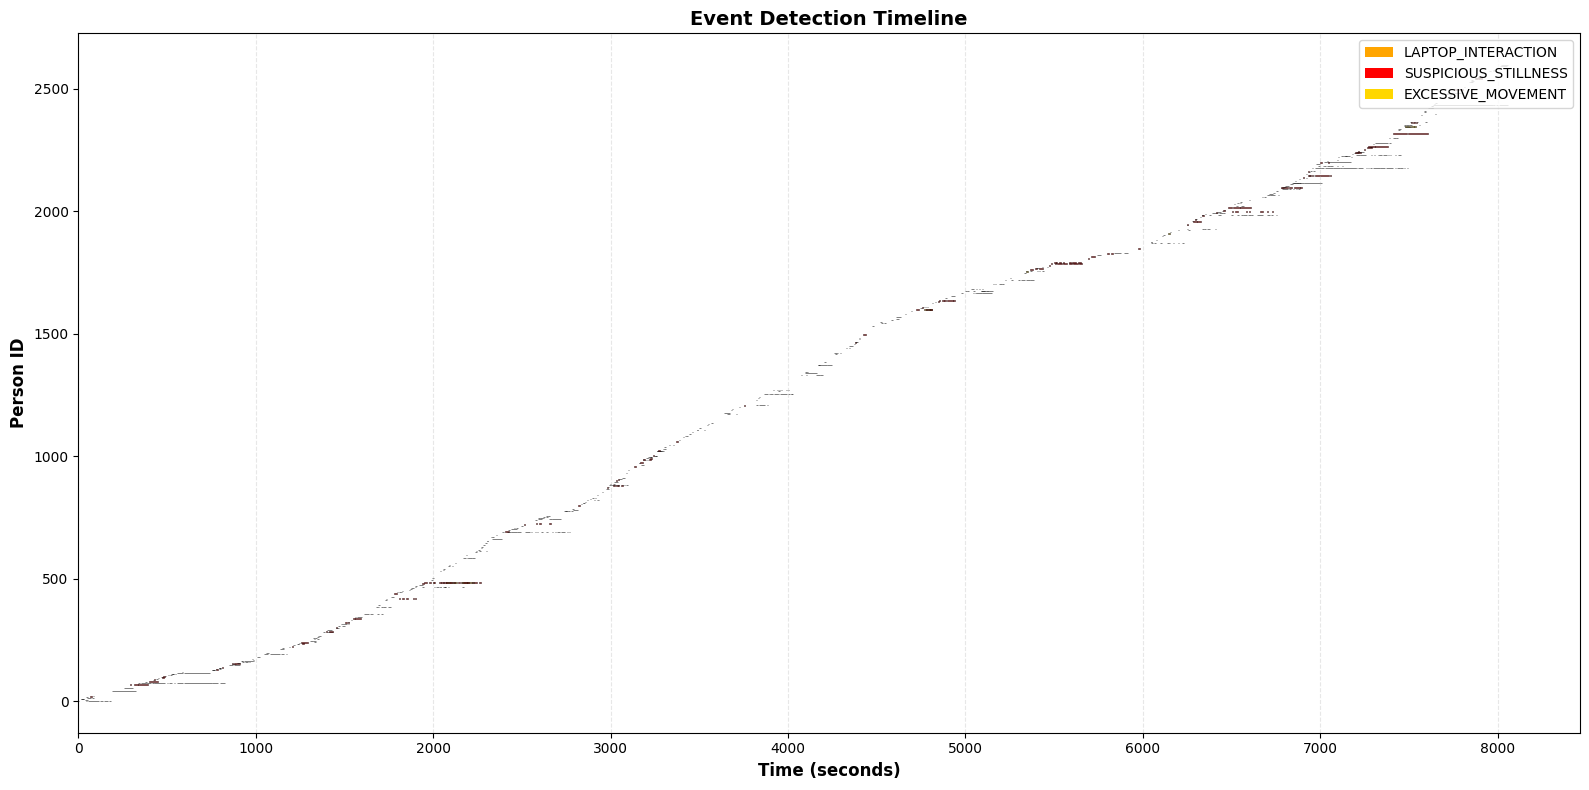

<Figure size 640x480 with 0 Axes>

✅ Timeline saved: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big//event_timeline.png


In [ ]:
  #cell 11
  if len(filtered_events) > 0:
      fig, ax = plt.subplots(figsize=(16, 8))

      # Color mapping
      color_map = {
          'LAPTOP_INTERACTION': 'orange',
          'SUSPICIOUS_STILLNESS': 'red',
          'EXCESSIVE_MOVEMENT': 'gold'
      }

      # Plot events
      for event in filtered_events:
          color = color_map.get(event['event_type'], 'gray')
          y_pos = event['person_id']

          ax.barh(y_pos, event['duration'], left=event['start_time'],
                  height=0.8, color=color, alpha=0.7,
                  edgecolor='black', linewidth=0.5)

      # Formatting
      ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
      ax.set_ylabel('Person ID', fontsize=12, fontweight='bold')
      ax.set_title('Event Detection Timeline', fontsize=14, fontweight='bold')
      ax.grid(axis='x', alpha=0.3, linestyle='--')

      # Legend
      from matplotlib.patches import Patch
      legend_elements = [Patch(facecolor=color, label=event_type)
                        for event_type, color in color_map.items()]
      ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

      plt.tight_layout()
      timeline_path = f"{PHASE2_OUTPUT_DIR}/event_timeline.png"
      plt.savefig(timeline_path, dpi=150, bbox_inches='tight')
      plt.show()

      # Formatting
      ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
      ax.set_ylabel('Person ID', fontsize=12, fontweight='bold')
      ax.set_title('Event Detection Timeline', fontsize=14, fontweight='bold')
      ax.grid(axis='x', alpha=0.3, linestyle='--')

      # Legend
      from matplotlib.patches import Patch
      legend_elements = [Patch(facecolor=color, label=event_type)
                        for event_type, color in color_map.items()]
      ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

      plt.tight_layout()
      timeline_path = f"{PHASE2_OUTPUT_DIR}/event_timeline.png"
      plt.savefig(timeline_path, dpi=150, bbox_inches='tight')
      plt.show()

      print(f"✅ Timeline saved: {timeline_path}")

      # Copy to Drive
      shutil.copy(timeline_path, f"{drive_output}/event_timeline.png")
  else:
      print("⚠️  No events to visualize")


In [ ]:
  with open(f"{PHASE2_OUTPUT_DIR}/events.json") as f:
      data = json.load(f)

  print(f"📊 Total Events: {data['metadata']['total_events']}")
  print(f"\n First 5 events:")
  for e in data['events'][:5]:
      print(f"  {e['event_id']}. [{e['severity']}] {e['event_type']} - Person {e['person_id']} at {e['start_time_formatted']}")

📊 Total Events: 754

 First 5 events:
  1. [HIGH] SUSPICIOUS_STILLNESS - Person 2 at 00:00
  2. [HIGH] SUSPICIOUS_STILLNESS - Person 10 at 00:13
  3. [HIGH] SUSPICIOUS_STILLNESS - Person 8 at 00:16
  4. [HIGH] SUSPICIOUS_STILLNESS - Person 2 at 00:43
  5. [HIGH] SUSPICIOUS_STILLNESS - Person 17 at 00:44


In [ ]:

  import cv2
  import subprocess
  from pathlib import Path

  # Configuration
  VIDEO_PATH = "/content/drive/MyDrive/ExamLens/videos/full_recording.mp4"
  CLIPS_OUTPUT_DIR = f"{PHASE2_OUTPUT_DIR}/evidence_clips/"
  Path(CLIPS_OUTPUT_DIR).mkdir(exist_ok=True)

  CONTEXT_SECONDS = 10  # Add10 seconds before/after event

  # Check if video exists
  if not Path(VIDEO_PATH).exists():
      print(f"❌ Video not found: {VIDEO_PATH}")
      print("   Update VIDEO_PATH to your actual video location")
  else:
      print(f"✅ Video found: {VIDEO_PATH}")

      # Get video info
      cap = cv2.VideoCapture(VIDEO_PATH)
      fps = cap.get(cv2.CAP_PROP_FPS)
      total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
      video_duration = total_frames / fps
      cap.release()

      print(f"📹 Video: {total_frames} frames @ {fps:.2f} fps ({video_duration:.1f}s)")

      # Extract clips for top events (limit to 10 to save time)
      events_to_extract = filtered_events[:10]

      print(f"\n🎬 Extracting clips for top {len(events_to_extract)} events...")
      print(f"   Context: ±{CONTEXT_SECONDS}s around each event")

      extracted_clips = []

      for event in tqdm(events_to_extract, desc="Extracting clips"):
          event_id = event['event_id']
          start_time = max(0, event['start_time'] - CONTEXT_SECONDS)
          end_time = min(video_duration, event['end_time'] + CONTEXT_SECONDS)
          duration = end_time - start_time

          # Output filename
          clip_filename = f"event_{event_id:03d}_{event['event_type'].lower()}_{event['person_id']}.mp4"
          clip_path = f"{CLIPS_OUTPUT_DIR}/{clip_filename}"

          # Use ffmpeg to extract clip
          ffmpeg_cmd = [
              'ffmpeg',
              '-y',  # Overwrite
              '-ss', str(start_time),  # Start time
              '-i', VIDEO_PATH,  # Input
              '-t', str(duration),  # Duration
              '-c:v', 'libx264',  # Video codec
              '-c:a', 'aac',  # Audio codec
              '-strict', 'experimental',
              '-loglevel', 'error',  # Quiet
              clip_path
          ]

          try:
              subprocess.run(ffmpeg_cmd, check=True, capture_output=True)

              # Verify clip created
              if Path(clip_path).exists():
                  clip_size = Path(clip_path).stat().st_size / (1024 * 1024)  # MB
                  extracted_clips.append({
                      'event_id': event_id,
                      'filename': clip_filename,
                      'path': clip_path,
                      'size_mb': clip_size,
                      'duration': duration,
                      'event_type': event['event_type'],
                      'person_id': event['person_id'],
                      'severity': event['severity']
                  })
          except subprocess.CalledProcessError as e:
              print(f"\n⚠️  Failed to extract clip for event {event_id}: {e}")

      print(f"\n✅ Extracted {len(extracted_clips)} clips")
      print(f"📁 Clips saved to: {CLIPS_OUTPUT_DIR}")

      # Show clip list
      print(f"\n📋 Evidence Clips:")
      print("-" * 80)
      for clip in extracted_clips:
          print(f"  {clip['event_id']:3d}. [{clip['severity']:6s}] {clip['filename']}")
          print(f"       {clip['duration']:.1f}s | {clip['size_mb']:.2f} MB | Person {clip['person_id']}")
      # Save clip index
      clips_index = {
          'total_clips': len(extracted_clips),
          'clips': extracted_clips
      }

      clips_json_path = f"{CLIPS_OUTPUT_DIR}/clips_index.json"
      with open(clips_json_path, 'w') as f:
          json.dump(clips_index, f, indent=2)

      print(f"\n✅ Clip index saved: {clips_json_path}")

      # Copy to Drive
      drive_clips_dir = "/content/drive/MyDrive/ExamLens/evidence_clips_big/"
      Path(drive_clips_dir).mkdir(parents=True, exist_ok=True)

      print(f"\n📦 Copying clips to Google Drive...")
      for clip in tqdm(extracted_clips, desc="Copying"):
          shutil.copy(clip['path'], drive_clips_dir)

      shutil.copy(clips_json_path, drive_clips_dir)

      print(f"✅ Clips backed up to: {drive_clips_dir}")


✅ Video found: /content/drive/MyDrive/ExamLens/videos/full_recording.mp4
📹 Video: 177365 frames @ 22.00 fps (8061.9s)

🎬 Extracting clips for top 10 events...
   Context: ±10s around each event


Extracting clips: 100%|██████████| 10/10 [05:14<00:00, 31.43s/it]



✅ Extracted 10 clips
📁 Clips saved to: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big//evidence_clips/

📋 Evidence Clips:
--------------------------------------------------------------------------------
    1. [HIGH  ] event_001_suspicious_stillness_2.mp4
       16.1s | 2.04 MB | Person 2
    2. [HIGH  ] event_002_suspicious_stillness_10.mp4
       40.0s | 4.75 MB | Person 10
    3. [HIGH  ] event_003_suspicious_stillness_8.mp4
       37.6s | 4.47 MB | Person 8
    4. [HIGH  ] event_004_suspicious_stillness_2.mp4
       25.9s | 2.99 MB | Person 2
    5. [HIGH  ] event_005_suspicious_stillness_17.mp4
       27.5s | 3.12 MB | Person 17
    6. [HIGH  ] event_006_suspicious_stillness_14.mp4
       40.6s | 4.06 MB | Person 14
    7. [HIGH  ] event_007_suspicious_stillness_2.mp4
       82.5s | 7.52 MB | Person 2
    8. [HIGH  ] event_008_suspicious_stillness_20.mp4
       29.8s | 2.84 MB | Person 20
    9. [HIGH  ] event_009_suspicious_stillness_14.mp4
       30.8s | 2.67 MB | P

Copying: 100%|██████████| 10/10 [00:00<00:00, 46.63it/s]

✅ Clips backed up to: /content/drive/MyDrive/ExamLens/evidence_clips_big/


📹 Video size: 1280x720
🔥 Accumulating activity from 177363 frames...


Building heatmap: 100%|██████████| 177363/177363 [00:16<00:00, 11068.19it/s]


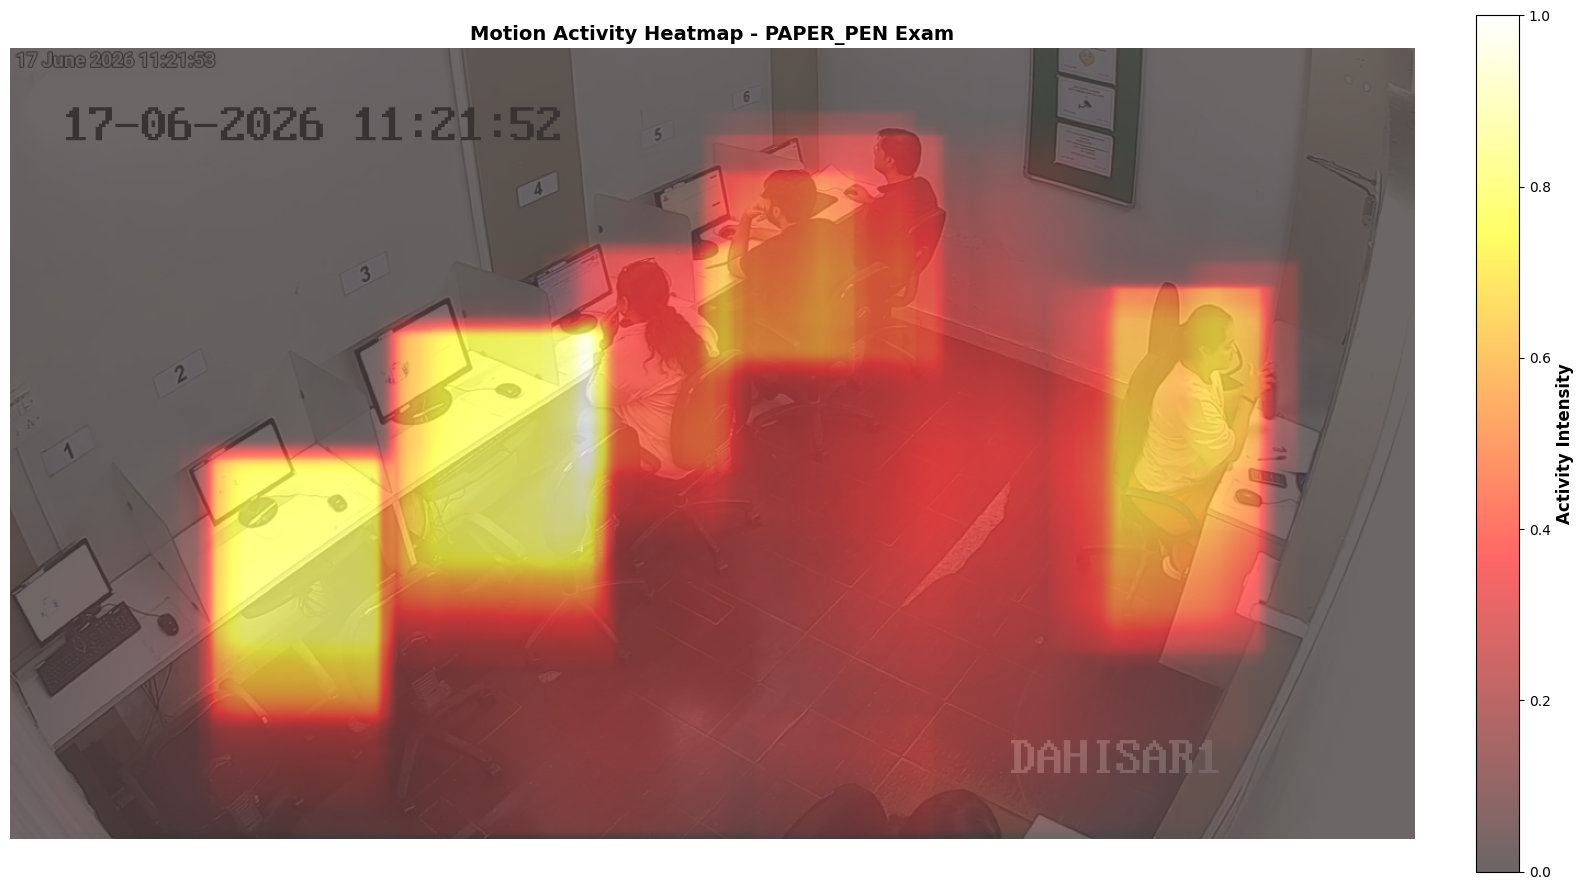

✅ Heatmap saved: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big//motion_heatmap.png
✅ Heatmap backed up to Drive


In [ ]:
  # CELL 14: Generate Motion Heatmap
  #----------------------------------------------------------------------------
  # Load video to get dimensions
  cap = cv2.VideoCapture(VIDEO_PATH)
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  ret, first_frame = cap.read()
  cap.release()

  print(f"📹 Video size: {width}x{height}")

  # Create heatmap accumulator
  heatmap = np.zeros((height, width), dtype=np.float32)

  print(f"🔥 Accumulating activity from {len(tracking_data)} frames...")

  # Accumulate person activity
  for frame_data in tqdm(tracking_data, desc="Building heatmap"):
      for det in frame_data['detections']:
          if det['class'] == 'person':
              x1, y1, x2, y2 = map(int, det['bbox'])
              motion_score = det.get('motion_score', 0.5)

              # Clip to frame bounds
              x1, x2 = max(0, x1), min(width, x2)
              y1, y2 = max(0, y1), min(height, y2)

              # Add weighted contribution
              heatmap[y1:y2, x1:x2] += motion_score

  # Normalize
  if heatmap.max() > 0:
      heatmap = heatmap / heatmap.max()

  # Visualize
  fig, ax = plt.subplots(figsize=(16, 9))

  if ret and first_frame is not None:
      first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
      ax.imshow(first_frame_rgb, alpha=0.5)

  im = ax.imshow(heatmap, cmap='hot', alpha=0.6, interpolation='bilinear')

  cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
  cbar.set_label('Activity Intensity', fontsize=12, fontweight='bold')

  ax.set_title(f'Motion Activity Heatmap - {EXAM_TYPE} Exam', fontsize=14, fontweight='bold')
  ax.axis('off')

  plt.tight_layout()
  heatmap_path = f"{PHASE2_OUTPUT_DIR}/motion_heatmap.png"
  plt.savefig(heatmap_path, dpi=150, bbox_inches='tight')
  plt.show()

  print(f"✅ Heatmap saved: {heatmap_path}")

  # Save heatmap data
  heatmap_data = {
      'exam_type': EXAM_TYPE,
      'width': width,
      'height': height,
      'max_value': float(heatmap.max()),
      'min_value': float(heatmap.min())
  }

  heatmap_json_path = f"{PHASE2_OUTPUT_DIR}/heatmap_data.json"
  with open(heatmap_json_path, 'w') as f:
      json.dump(heatmap_data, f, indent=2)

  # Backup to Drive
  drive_output = "/content/drive/MyDrive/ExamLens/phase2_output_big/"
  Path(drive_output).mkdir(parents=True, exist_ok=True)
  shutil.copy(heatmap_path, drive_output)
  shutil.copy(heatmap_json_path, drive_output)

  print("✅ Heatmap backed up to Drive")

In [ ]:
  # CELL 15: Generate Investigation Report
  #----------------------------------------------------------------------------

  report = {
      "exam_info": {
          "exam_type": EXAM_TYPE,
          "exam_description": EXAM_PROFILE['description']
      },
      "video_info": {
          "filename": VIDEO_PATH.split('/')[-1],
          "total_frames": len(tracking_data),
          "duration_seconds": tracking_data[-1]['timestamp'] if len(tracking_data) > 0 else 0,
          "resolution": f"{width}x{height}"
      },
      "processing_summary": {
          "persons_tracked": len(person_tracks),
          "total_detections": summary['total_detections'],
          "detections_per_frame": summary.get('average_detections_per_frame', 0)
      },
      "events_summary": {
          "total_events": len(filtered_events),
          "high_severity": len([e for e in filtered_events if e['severity'] == 'HIGH']),
          "medium_severity": len([e for e in filtered_events if e['severity'] == 'MEDIUM']),
          "by_type": dict(event_summary)
      },
      "investigation_priority": {
          "immediate_review": [
              {
                  "event_id": e['event_id'],
                  "type": e['event_type'],
                  "person": e['person_id'],
                  "time": e['start_time_formatted'],
                  "duration": f"{e['duration']:.1f}s"
              }
              for e in filtered_events if e['severity'] == 'HIGH'
          ][:10],
          "secondary_review": [
              {
                  "event_id": e['event_id'],
                  "type": e['event_type'],
                  "person": e['person_id'],
                  "time": e['start_time_formatted']
              }
              for e in filtered_events if e['severity'] == 'MEDIUM'
          ][:10]
      },
      "recommendations": {
          "manual_review_required": len([e for e in filtered_events if e['severity'] == 'HIGH']),
          "estimated_review_time_minutes": len(filtered_events) * 2,
          "attention_persons": list(set([e['person_id'] for e in filtered_events if e['severity'] == 'HIGH']))
      }
  }

  report_path = f"{PHASE2_OUTPUT_DIR}/investigation_report.json"
  with open(report_path, 'w') as f:
      json.dump(report, f, indent=2)

  shutil.copy(report_path, drive_output)

  print(f"✅ Report saved: {report_path}")
  print("\n📊 Investigation Summary:")
  print(f"   Exam Type: {EXAM_TYPE}")
  print(f"   Total Events: {report['events_summary']['total_events']}")
  print(f"   HIGH Severity: {report['events_summary']['high_severity']}")
  print(f"   MEDIUM Severity: {report['events_summary']['medium_severity']}")
  print(f"   Estimated Review Time: {report['recommendations']['estimated_review_time_minutes']} minutes")
  print(f"Persons Requiring Attention: {len(report['recommendations']['attention_persons'])}")

✅ Report saved: /content/drive/MyDrive/ExamLens/examlens_phase2_events_big//investigation_report.json

📊 Investigation Summary:
   Exam Type: PAPER_PEN
   Total Events: 754
   HIGH Severity: 729
   MEDIUM Severity: 25
   Estimated Review Time: 1508 minutes
Persons Requiring Attention: 405
